In [78]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------- ------------------------------ 1.8/8.1 MB 10.0 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 9.8 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 9.2 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 8.3 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 7.2 MB/s  0:00:01
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:-


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv('cafeteria_data_full_quarter.csv')

print(f"✅ Data Loaded. Total Records: {len(df)}")

✅ Data Loaded. Total Records: 248


In [3]:

# 2. PREPROCESSING (The "Unified" Step)

# We define the Inputs (Features) and Output (Target)
# Note: We include Weather, Calendar Events, and Meal Info all together.
features = ['Day_of_Week', 'Meal_Type', 'Is_Veg', 'Event_Context', 'Weather']
target = 'Qty_Consumed'

In [4]:
# Convert text labels (e.g., "Monday", "Rainy") into numbers the AI understands
# This uses "One-Hot Encoding" on a chosen feature set (see engineered features added next)
y = df[target]

In [5]:
# -------------------------------
# Feature engineering: Event flags + optional Item_Category
# -------------------------------
# Create boolean flags so the model can explicitly learn exam/holiday/graduation effects
df['Is_Exam_Week'] = df.get('Event_Context', '').astype(str).str.contains('exam', case=False, na=False)
df['Is_Holiday'] = df.get('Event_Context', '').astype(str).str.contains('holiday|break', case=False, na=False)
df['Is_Graduation'] = df.get('Event_Context', '').astype(str).str.contains('graduation|convocation', case=False, na=False)
# If an item/category column exists, include it so forecasts can be broken down by category
additional_features = ['Is_Exam_Week','Is_Holiday','Is_Graduation']
if 'Item_Category' in df.columns:
    additional_features.append('Item_Category')
# Build final feature list used for modeling
features_to_use = features + additional_features
print('Features used for modeling:', features_to_use)

Features used for modeling: ['Day_of_Week', 'Meal_Type', 'Is_Veg', 'Event_Context', 'Weather', 'Is_Exam_Week', 'Is_Holiday', 'Is_Graduation']


In [6]:
# Debug: inspect processed features
# Encode using features_to_use (fall back if not defined)
features_for_encoding = globals().get('features_to_use', features)
X = pd.get_dummies(df[features_for_encoding])
print('Columns count:', len(X.columns))
print('Sample columns:', X.columns[:12].tolist())
print('Object/string dtypes in X:', X.select_dtypes(include=['object','string']).columns.tolist())
print(X.head().T.sample(8))

Columns count: 46
Sample columns: ['Is_Veg', 'Is_Exam_Week', 'Is_Holiday', 'Is_Graduation', 'Day_of_Week_FRI', 'Day_of_Week_MON', 'Day_of_Week_SAT', 'Day_of_Week_SUN', 'Day_of_Week_THU', 'Day_of_Week_TUE', 'Day_of_Week_WED', 'Meal_Type_BREAKFAST']
Object/string dtypes in X: []
                                0      1      2      3      4
Event_Context_Diwali        False  False  False  False  False
Is_Exam_Week                False  False  False  False  False
Event_Context_Weekend       False  False  False  False   True
Event_Context_Reopen_Day    False  False  False  False  False
Is_Veg                       True  False   True  False   True
Day_of_Week_SUN             False  False  False  False  False
Event_Context_Post_Cyclone  False  False  False  False  False
Day_of_Week_FRI             False  False  False  False  False


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. TRAINING THE ENGINE
# (The Core AI Model)
# ==========================================
print("\n🧠 Training the Unified Model...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("✅ Training Complete.")
# -------------------------------
# Hyperparameter tuning (GridSearchCV) — quick scan
# -------------------------------
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators':[50,100,200], 'max_depth':[None,10,20]}
gs = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
gs.fit(X_train, y_train)
print('Best params (GridSearch):', gs.best_params_)
best_model = gs.best_estimator_
# Evaluate tuned model on test set
preds_gs = best_model.predict(X_test)
mae_gs = mean_absolute_error(y_test, preds_gs)
print(f'Tuned model MAE: {mae_gs:.2f}')


🧠 Training the Unified Model...
✅ Training Complete.
Best params (GridSearch): {'max_depth': 20, 'n_estimators': 200}
Tuned model MAE: 17.67


In [8]:
# -------------------------------------------------------
# USER STORY 1.5: ADMIN ACCURACY REPORT
# "As an Admin, I want to track forecast accuracy..."
# -------------------------------------------------------

# Use tuned model if available (best_model), otherwise fallback to original model
use_model = globals().get('best_model', model)
predictions = use_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
accuracy_percentage = 100 - (mae / y_test.mean() * 100)

print("\n" + "="*40)
print("📊 ADMIN REPORT (User Story 1.5)")
print("="*40)
print(f"Model Accuracy: {accuracy_percentage:.2f}%")
print(f"Average Error:  +/- {mae:.1f} plates")
print("(This means if the model predicts 300, the real demand is usually between 284 and 316)")


📊 ADMIN REPORT (User Story 1.5)
Model Accuracy: 86.10%
Average Error:  +/- 17.7 plates
(This means if the model predicts 300, the real demand is usually between 284 and 316)


In [9]:
# -------------------------------------------------------
# USER STORY 1.6: ANALYST INSIGHTS
# "As a User, I want to see how weather/events impact demand..."
# -------------------------------------------------------
# Use feature importances from tuned model if available
fi_model = globals().get('best_model', model)
feature_importances = pd.DataFrame({
    'Factor': X.columns,
    'Importance': fi_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n" + "="*40)
print("🧐 ANALYST INSIGHTS (User Story 1.6)")
print("="*40)
print("Top 5 Drivers of Demand Changes:")
print(feature_importances.head(5).to_string(index=False))
print("\n(Note: If 'Event_Context' or 'Weather' is high, it proves User Stories 1.2 & 1.3 are working)")


🧐 ANALYST INSIGHTS (User Story 1.6)
Top 5 Drivers of Demand Changes:
                       Factor  Importance
Event_Context_Winter_Vacation    0.418039
        Event_Context_Weekend    0.154487
                   Is_Holiday    0.082743
                 Is_Exam_Week    0.047744
          Meal_Type_BREAKFAST    0.032648

(Note: If 'Event_Context' or 'Weather' is high, it proves User Stories 1.2 & 1.3 are working)


In [14]:
# -------------------------------------------------------
# USER STORY 1.1: KITCHEN MANAGER DASHBOARD
# "As a Manager, I want accurate forecasts for tomorrow..."
# -------------------------------------------------------
print("\n" + "="*40)
print("👨‍🍳 KITCHEN MANAGER DASHBOARD (User Story 1.1)")
print("="*40)

# Let's simulate a prediction for "Tomorrow"
# Scenario: Tomorrow is Monday, End Sem Exams are ON, and it is Cold.
tomorrow_scenario = pd.DataFrame([{
    'Day_of_Week': 'MON',
    'Meal_Type': 'DINNER',
    'Is_Veg': True,
    'Event_Context': 'NORMAL', # <--- The AI sees "Exam" and boosts the number
    'Weather': 'Cloudy'                 # <--- The AI sees "Cold" and adjusts accordingly
}])


👨‍🍳 KITCHEN MANAGER DASHBOARD (User Story 1.1)


In [15]:
# -------------------------------
# Per-item-category forecasting (if available)
# -------------------------------
if 'Item_Category' in df.columns:
    print('Item_Category column found — training small per-category models for sample forecasts')
    cats = df['Item_Category'].dropna().unique()
    sample_cat_results = {}
    for cat in cats[:6]:
        dfc = df[df['Item_Category'] == cat]
        if len(dfc) < 20:
            continue
        Xc = pd.get_dummies(dfc[globals().get('features_to_use', features)])
        Xc = Xc.reindex(columns=X.columns, fill_value=0)
        yc = dfc[target]
        Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)
        mc = RandomForestRegressor(n_estimators=100, random_state=42)
        mc.fit(Xc_train, yc_train)
        preds = mc.predict(Xc_test)
        sample_cat_results[cat] = {'mae': float(mean_absolute_error(yc_test, preds)), 'sample_pred_mean': float(preds.mean())}
    print('Per-category sample summary (first 6 categories):')
    print(sample_cat_results)
else:
    print('No Item_Category column present — skipping per-category forecast step')

No Item_Category column present — skipping per-category forecast step


Using Date for time-based aggregation


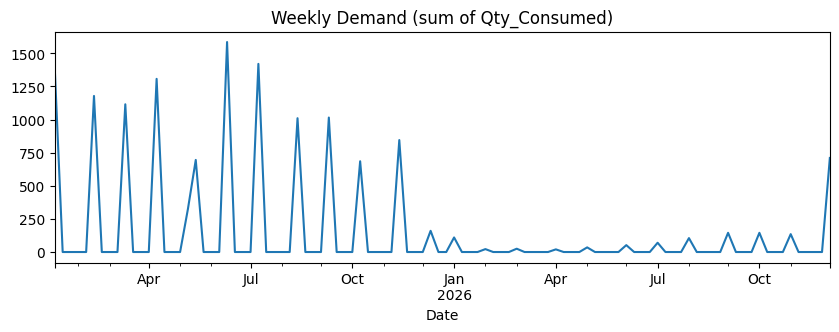

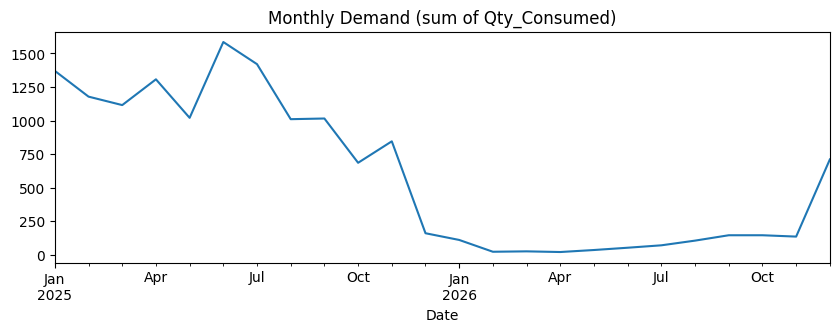

In [16]:
# -------------------------------
# Weekly and monthly demand trends
# -------------------------------
# Try to locate a date-like column automatically
date_col = None
for c in df.columns:
    if 'date' in c.lower() or 'day' in c.lower() and c.lower() != 'day_of_week':
        date_col = c
        break
if date_col is not None:
    print('Using', date_col, 'for time-based aggregation')
    ts = df.copy()
    ts[date_col] = pd.to_datetime(ts[date_col], errors='coerce')
    ts = ts.dropna(subset=[date_col])
    weekly = ts.set_index(date_col).resample('W')[target].sum()
    # Use 'ME' (month end) which is compatible with newer pandas offsets
    monthly = ts.set_index(date_col).resample('ME')[target].sum()
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10,3))
        weekly.plot(title='Weekly Demand (sum of Qty_Consumed)')
        plt.show()
        plt.figure(figsize=(10,3))
        monthly.plot(title='Monthly Demand (sum of Qty_Consumed)')
        plt.show()
    except ModuleNotFoundError:
        print('matplotlib not installed — showing aggregated values instead')
        print('Weekly (last 10):')
        print(weekly.tail(10))
        print('Monthly (last 6):')
        print(monthly.tail(6))
else:
    print('No suitable date column found — cannot generate weekly/monthly trends')

In [17]:
tomorrow_encoded = pd.get_dummies(tomorrow_scenario)
tomorrow_encoded = tomorrow_encoded.reindex(columns=X.columns, fill_value=0)

forecast_value = model.predict(tomorrow_encoded)[0]

print(f"🔮 FORECAST FOR TOMORROW {tomorrow_scenario.iloc[0]['Day_of_Week']} ({tomorrow_scenario.iloc[0]['Meal_Type']}):")
print(f"Context: {tomorrow_scenario.iloc[0]['Event_Context']} | Weather: {tomorrow_scenario.iloc[0]['Weather']}")
print(f"👉 PREPARE: {int(forecast_value)} PLATES")
print("="*40)

🔮 FORECAST FOR TOMORROW MON (DINNER):
Context: NORMAL | Weather: Cloudy
👉 PREPARE: 188 PLATES
